In [2]:
# BiLSTM-based Intrusion Detection on TON IoT Dataset (Rewritten)

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from collections import Counter
from sklearn.model_selection import StratifiedKFold, train_test_split

# Load Dataset
df = pd.read_csv('../dataset/final_df.csv', low_memory=False)
print("Original DataFrame Head:\n", df.head())
print("\nOriginal Class Distribution:\n", df['type'].value_counts())
print("\nOriginal Label Distribution:\n", df['label'].value_counts())
print("\nOriginal Data Types:\n", df.dtypes)
print("\nOriginal Data Shapes:\n", df.shape)

# --- Data Preprocessing ---
# Clean and impute
df['src_bytes'] = pd.to_numeric(df['src_bytes'], errors='coerce').fillna(0)
df.drop_duplicates(inplace=True)

df.fillna(df.mean(numeric_only=True), inplace=True)
print(f"Shape after dropping duplicates: {df.shape}")

for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype == 'object':
            df[col].fillna('Missing', inplace=True) # Or df[col].mode()[0]
        else:
            df[col].fillna(df[col].mean(), inplace=True)

print(f"Shape after handling NaNs: {df.shape}")

# Identify targets
TARGET_LABEL = 'label'
TARGET_TYPE = 'type'

# Encode categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()
if TARGET_TYPE in categorical_cols:
    categorical_cols.remove(TARGET_TYPE)

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f"Encoded column: {col}")

# Normalize numerical features
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if TARGET_LABEL in numerical_cols:
    numerical_cols.remove(TARGET_LABEL)

print(f"\nCategorical columns: {categorical_cols}")
print(f"Numerical columns: {numerical_cols}")

binary_y = df[TARGET_LABEL].values
type_encoder = LabelEncoder()
y_multiclass_encoded = type_encoder.fit_transform(df[TARGET_TYPE])
num_classes = len(le.classes_)
# Convert to one-hot encoding for Keras if using categorical_crossentropy
y_multiclass_onehot = to_categorical(y_multiclass_encoded)

y_multiclass_labels = np.argmax(y_multiclass_onehot, axis=1)

# Drop targets from features
X = df.drop(columns=[TARGET_LABEL, TARGET_TYPE]).values
print("Feature shape (flat):", X.shape)
print("Binary target shape:", binary_y.shape)
print("Multi-class target shape:", y_multiclass_labels.shape)

# print the class distribution of binary_y and y_multiclass_labels
print("Binary target class distribution:")
print(Counter(binary_y))
print("Multi-class target class distribution:")
print(Counter(y_multiclass_labels))

2025-11-16 19:54:08.580241: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-16 19:54:08.974954: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-16 19:54:10.327298: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Original DataFrame Head:
            ts         src_ip  src_port        dst_ip  dst_port proto service  \
0  1556499101  192.168.1.193     60396  192.168.1.33      8080   tcp       -   
1  1556494424  192.168.1.193     59273  192.168.1.33      8080   tcp       -   
2  1556487945  192.168.1.193     57717  192.168.1.33      8080   tcp       -   
3  1556508616  192.168.1.193     62682  192.168.1.33        80   tcp       -   
4  1556511697  192.168.1.193     63419  192.168.1.33      8080   tcp       -   

   duration src_bytes  dst_bytes  ... http_response_body_len  \
0  0.000180         0          0  ...                      0   
1  0.000111         0          0  ...                      0   
2  0.000148         0          0  ...                      0   
3  0.000127         0          0  ...                      0   
4  0.000122         0          0  ...                      0   

   http_status_code  http_user_agent  http_orig_mime_types  \
0                 0                -          

In [3]:
# 1. Split BEFORE SMOTE (to avoid leakage)
# ----------------------------------------
X_train, X_test, y_train_multi, y_test_multi = train_test_split(
    X,
    y_multiclass_onehot,
    test_size=0.2,
    random_state=42,
    stratify=y_multiclass_encoded
)

# Reset indices
X_train = pd.DataFrame(X_train).reset_index(drop=True).values
X_test = pd.DataFrame(X_test).reset_index(drop=True).values

print(f"\nX_train shape: {X_train.shape}")
print(f"y_train_multiclass labels shape: {y_train_multi.shape}")
print(f"X_test  shape: {X_test.shape}")
print(f"y_test_multiclass labels shape: {y_test_multi.shape}")

# print the class distribution of binary_y and y_multiclass
# print the class distribution of binary_y and y_multiclass
print("Multi-class target class distribution (train):")
print(Counter(np.argmax(y_train_multi, axis=1)))
print("Multi-class target class distribution (test):")
print(Counter(np.argmax(y_test_multi, axis=1)))

# scaling the training data
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling complete.")


X_train shape: (352834, 44)
y_train_multiclass labels shape: (352834, 9)
X_test  shape: (88209, 44)
y_test_multiclass labels shape: (88209, 9)
Multi-class target class distribution (train):
Counter({np.int64(5): 240000, np.int64(0): 16000, np.int64(6): 16000, np.int64(7): 16000, np.int64(8): 16000, np.int64(2): 16000, np.int64(1): 16000, np.int64(3): 16000, np.int64(4): 834})
Multi-class target class distribution (test):
Counter({np.int64(5): 60000, np.int64(1): 4000, np.int64(3): 4000, np.int64(6): 4000, np.int64(0): 4000, np.int64(8): 4000, np.int64(7): 4000, np.int64(2): 4000, np.int64(4): 209})
Scaling complete.


In [4]:
# --- Create Sequences ---
def create_sequences(
    X,
    y,
    window_size: int = 10,
    debug: bool = False,
    trace_limit: int = 5
):
    # Convert to numpy if not already
    X = np.asarray(X)
    y = np.asarray(y)

    # Input validation
    if len(X) != len(y):
        raise ValueError("X and y must have the same number of samples")
    if len(X.shape) != 2:
        raise ValueError("X must be a 2D array: (samples, features)")
    if len(y.shape) > 2:
        raise ValueError("y must be a 1D or 2D array")

    X_seq, y_seq = [], []
    total = len(X) - window_size + 1
    if debug:
        print(f"Total samples: {len(X)} | Generating {total} sequences (window_size={window_size})")

    for i in range(total):
        window = X[i : i + window_size]
        label = y[i + window_size - 1]
        X_seq.append(window)
        y_seq.append(label)

        if debug and i < trace_limit:
            print(f"\n--- Seq {i+1}/{total} ---")
            print(f"  X indices: {i} to {i+window_size-1}")
            print(f"  y index:   {i+window_size-1} → label={label}")
            print(f"  window.shape: {window.shape}")

    if debug:
        print(f"\nTotal sequences generated: {len(X_seq)}")

    return np.array(X_seq), np.array(y_seq)


TIMESTEPS = 10
X_train_seq, y_train_seq = create_sequences(X_train, y_train_multi, window_size=TIMESTEPS, debug=True)
X_test_seq, y_test_seq = create_sequences(X_test, y_test_multi, window_size=TIMESTEPS, debug=True)


print("Train sequence shape:", X_train_seq.shape)  # (samples, timesteps, features)
print("Test sequence shape:", X_test_seq.shape)
print("multi target distribution:", Counter(np.argmax(y_train_multi, axis=1)))

# counters
print("Class distribution in y_train_seq:", Counter(np.argmax(y_train_seq, axis=1)))
print("Class distribution in y_test_seq:", Counter(np.argmax(y_test_seq, axis=1)))

# multiclass sequence generation.
# X_train_seq_multi, y_train_seq_multi = create_sequences(X_train, y_train_multi, debug=True)
# X_test_seq_multi, y_test_seq_multi = create_sequences(X_test, y_test_multi, debug=True)


Total samples: 352834 | Generating 352825 sequences (window_size=10)

--- Seq 1/352825 ---
  X indices: 0 to 9
  y index:   9 → label=[0. 0. 0. 0. 0. 0. 0. 1. 0.]
  window.shape: (10, 44)

--- Seq 2/352825 ---
  X indices: 1 to 10
  y index:   10 → label=[0. 0. 0. 0. 0. 1. 0. 0. 0.]
  window.shape: (10, 44)

--- Seq 3/352825 ---
  X indices: 2 to 11
  y index:   11 → label=[0. 0. 0. 0. 0. 0. 0. 0. 1.]
  window.shape: (10, 44)

--- Seq 4/352825 ---
  X indices: 3 to 12
  y index:   12 → label=[0. 0. 0. 0. 0. 1. 0. 0. 0.]
  window.shape: (10, 44)

--- Seq 5/352825 ---
  X indices: 4 to 13
  y index:   13 → label=[0. 0. 0. 0. 0. 1. 0. 0. 0.]
  window.shape: (10, 44)

Total sequences generated: 352825
Total samples: 88209 | Generating 88200 sequences (window_size=10)

--- Seq 1/88200 ---
  X indices: 0 to 9
  y index:   9 → label=[0. 0. 0. 0. 0. 0. 0. 0. 1.]
  window.shape: (10, 44)

--- Seq 2/88200 ---
  X indices: 1 to 10
  y index:   10 → label=[0. 0. 0. 0. 0. 1. 0. 0. 0.]
  window.shap

In [6]:
from sklearn.utils import shuffle

X_train_seq_bal_shuffle, y_train_seq_bal_shuffle = shuffle(X_train_seq, y_train_seq, random_state=42)

# Shuffle with stratification in mind
shuffled_data = list(zip(X_train_seq_bal_shuffle, y_train_seq_bal_shuffle))
shuffled_data = shuffle(shuffled_data, random_state=42)
X_shuffled, y_shuffled = zip(*shuffled_data)

# Convert back to arrays
X_shuffled = np.array(X_shuffled)
y_shuffled = np.array(y_shuffled)

# Now split
val_fraction = 0.2
n_total = X_shuffled.shape[0]
n_val = int(n_total * val_fraction)

X_val_seq = X_shuffled[-n_val:]
y_val_seq = y_shuffled[-n_val:]
X_train_seq_final = X_shuffled[:-n_val]
y_train_seq_final = y_shuffled[:-n_val]

print("Final training shapes:")
print(f"X_train_seq_final shape: {X_train_seq_final.shape}")
print(f"y_train_seq_final shape: {y_train_seq_final.shape}")
print(f"X_val_seq shape: {X_val_seq.shape}")
print(f"y_val_seq shape: {y_val_seq.shape}")

print("Final training label distributions:")
print(f"y_train_seq_final distribution: {Counter(np.argmax(y_train_seq_final, axis=1))}")
print(f"y_val_seq distribution: {Counter(np.argmax(y_val_seq, axis=1))}")

Final training shapes:
X_train_seq_final shape: (282260, 10, 44)
y_train_seq_final shape: (282260, 9)
X_val_seq shape: (70565, 10, 44)
y_val_seq shape: (70565, 9)
Final training label distributions:
y_train_seq_final distribution: Counter({np.int64(5): 191884, np.int64(3): 12862, np.int64(1): 12859, np.int64(7): 12841, np.int64(6): 12835, np.int64(8): 12785, np.int64(0): 12772, np.int64(2): 12761, np.int64(4): 661})
y_val_seq distribution: Counter({np.int64(5): 48110, np.int64(2): 3239, np.int64(0): 3227, np.int64(8): 3215, np.int64(6): 3164, np.int64(7): 3158, np.int64(1): 3141, np.int64(3): 3138, np.int64(4): 173})


In [ ]:
# from sklearn.utils import shuffle

# # X_train_seq_bal_shuffle, y_train_seq_bal_shuffle = shuffle(X_train_res, y_train_res, random_state=42)
# X_train_seq_bal_shuffle, y_train_seq_bal_shuffle = shuffle(X_train_seq, y_train_seq, random_state=42)

# val_fraction = 0.2
# n_total = X_train_seq_bal_shuffle.shape[0]
# n_val = int(n_total * val_fraction)

# X_val_seq = X_train_seq_bal_shuffle[-n_val:]
# y_val_seq = y_train_seq_bal_shuffle[-n_val:]
# X_train_seq_final = X_train_seq_bal_shuffle[:-n_val]
# y_train_seq_final = y_train_seq_bal_shuffle[:-n_val]

# print("Final training shapes:")
# print(f"X_train_seq_final shape: {X_train_seq_final.shape}")
# print(f"y_train_seq_final shape: {y_train_seq_final.shape}")
# print(f"X_val_seq shape: {X_val_seq.shape}")
# print(f"y_val_seq shape: {y_val_seq.shape}")

# print("Final training label distributions:")
# print(f"y_train_seq_final distribution: {Counter(np.argmax(y_train_seq_final, axis=1))}")
# print(f"y_val_seq distribution: {Counter(np.argmax(y_val_seq, axis=1))}")

Final training shapes:
X_train_seq_final shape: (282260, 10, 44)
y_train_seq_final shape: (282260, 9)
X_val_seq shape: (70565, 10, 44)
y_val_seq shape: (70565, 9)
Final training label distributions:
y_train_seq_final distribution: Counter({np.int64(5): 191864, np.int64(2): 12852, np.int64(0): 12842, np.int64(1): 12832, np.int64(7): 12817, np.int64(6): 12809, np.int64(3): 12793, np.int64(8): 12789, np.int64(4): 662})
y_val_seq distribution: Counter({np.int64(5): 48130, np.int64(8): 3211, np.int64(3): 3207, np.int64(6): 3190, np.int64(7): 3182, np.int64(1): 3168, np.int64(0): 3157, np.int64(2): 3148, np.int64(4): 172})


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.metrics import Precision
from tensorflow.keras.layers import LayerNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Recall, AUC
from sklearn.metrics import (confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, matthews_corrcoef, roc_auc_score, classification_report, roc_curve, precision_recall_curve)
import matplotlib.pyplot as plt


# Model definition
model = Sequential([
    Bidirectional(LSTM(
        128,                       
        return_sequences=True,
        recurrent_dropout=0.15,
        recurrent_activation='sigmoid',
        activation='tanh',
        kernel_regularizer=l2(1e-5)
    ), input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    LayerNormalization(),
    Dropout(0.3),

    Bidirectional(LSTM(
        64,
        recurrent_dropout=0.15,
        recurrent_activation='sigmoid', 
        activation='tanh',
        kernel_regularizer=l2(1e-5)
    )),
    LayerNormalization(),
    Dropout(0.3),

    # Dense(64, activation='relu', kernel_regularizer=l2(1e-5)),
    # Dropout(0.25),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(9, activation='softmax')
])

model.summary()

optimizer = Adam(
    learning_rate=0.0001,  # Very low initial LR 0.0002 <> 0.0001
    clipnorm=1.0,  # Gradient clipping to prevent exploding gradients
)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        AUC(name='auc'),
        Recall(name='recall'),
        Precision(name='precision')
    ]
)

# Early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    mode='min',
    restore_best_weights=True,
    verbose=1
)


# Train
history = model.fit(
    X_train_seq_final, y_train_seq_final,
    validation_data=(X_val_seq, y_val_seq),
    epochs=20,
    batch_size=128,
    shuffle=True,
    callbacks=[early_stopping],
    verbose=1
)

results = model.evaluate(X_test_seq, y_test_seq, verbose=2)

print("Test Loss: {}".format(results[0]))
print("Test Accuracy: {}".format(results[1]))


I0000 00:00:1763302520.022159    8306 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2278 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2050, pci bus id: 0000:01:00.0, compute capability: 8.6
/home/jinesh-subedi/htdocs/thesis/thesisStudy/lib/python3.12/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 10, 256)        │       177,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 10, 256)        │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 128)            │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 346,697 (1.32 MB)

 Trainable params: 346,697 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
2206/2206 ━━━━━━━━━━━━━━━━━━━━ 104s 43ms/step - accuracy: 0.7004 - auc: 0.9404 - loss: 0.9461 - precision: 0.8450 - recall: 0.5846 - val_accuracy: 0.8123 - val_auc: 0.9828 - val_loss: 0.5343 - val_precision: 0.9217 - val_recall: 0.6971
Epoch 2/20
2206/2206 ━━━━━━━━━━━━━━━━━━━━ 91s 41ms/step - accuracy: 0.7942 - auc: 0.9803 - loss: 0.5513 - precision: 0.9038 - recall: 0.7137 - val_accuracy: 0.8582 - val_auc: 0.9897 - val_loss: 0.3919 - val_precision: 0.9321 - val_recall: 0.7888
Epoch 3/20
2206/2206 ━━━━━━━━━━━━━━━━━━━━ 92s 41ms/step - accuracy: 0.8422 - auc: 0.9876 - loss: 0.4305 - precision: 0.9108 - recall: 0.7808 - val_accuracy: 0.9004 - val_auc: 0.9937 - val_loss: 0.2883 - val_precision: 0.9446 - val_recall: 0.8576
Epoch 4/20
2206/2206 ━━━━━━━━━━━━━━━━━━━━ 92s 42ms/step - accuracy: 0.8791 - auc: 0.9917 - loss: 0.3407 - precision: 0.9185 - recall: 0.8411 - val_accuracy: 0.9239 - val_auc: 0.9958 - val_loss: 0.2339 - val_precision: 0.9463 - val_recall: 0.9146
Epoch 5/20
2206

['backdoor' 'ddos' 'dos' 'injection' 'mitm' 'normal' 'password' 'scanning'
 'xss']
Encoded class 0 -> backdoor
Encoded class 1 -> ddos
Encoded class 2 -> dos
Encoded class 3 -> injection
Encoded class 4 -> mitm
Encoded class 5 -> normal
Encoded class 6 -> password
Encoded class 7 -> scanning
Encoded class 8 -> xss
2757/2757 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3999
           1       0.92      0.97      0.95      3999
           2       0.98      0.94      0.96      4000
           3       0.95      0.98      0.96      3999
           4       0.62      0.39      0.48       209
           5       0.99      0.99      0.99     59995
           6       0.96      0.99      0.98      3999
           7       0.98      0.99      0.98      4000
           8       0.98      0.97      0.97      4000

    accuracy                           0.98     88200
   macro avg       0.93      0.91      0.92 

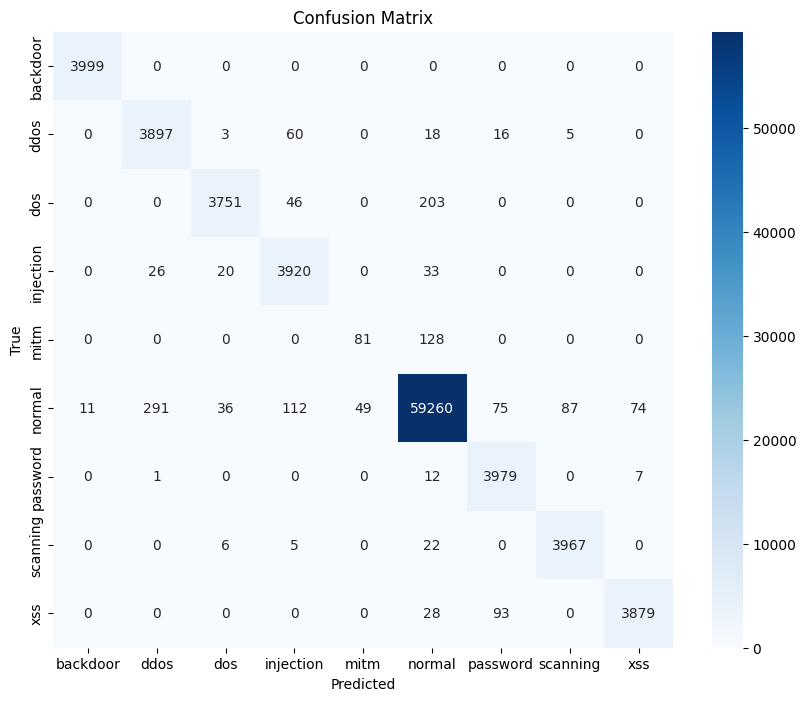

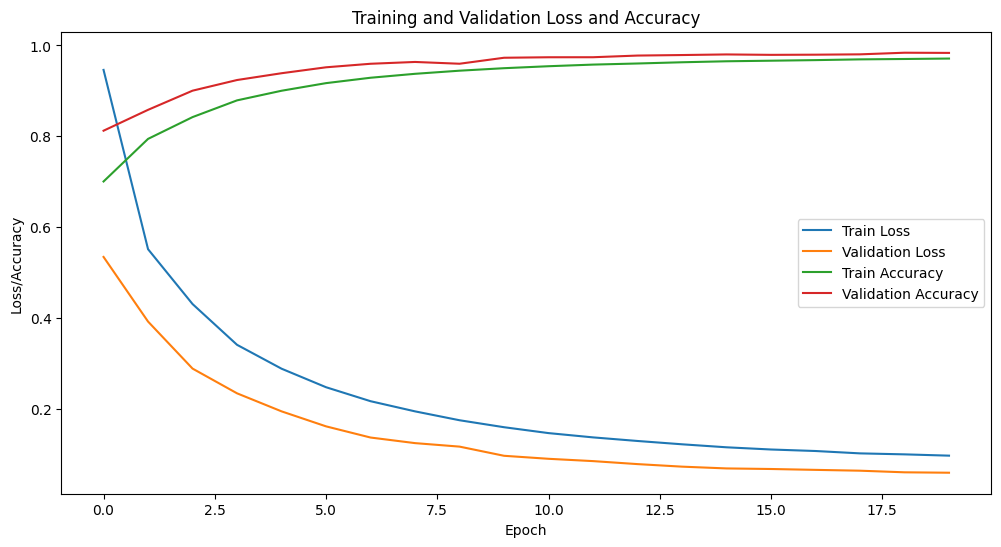

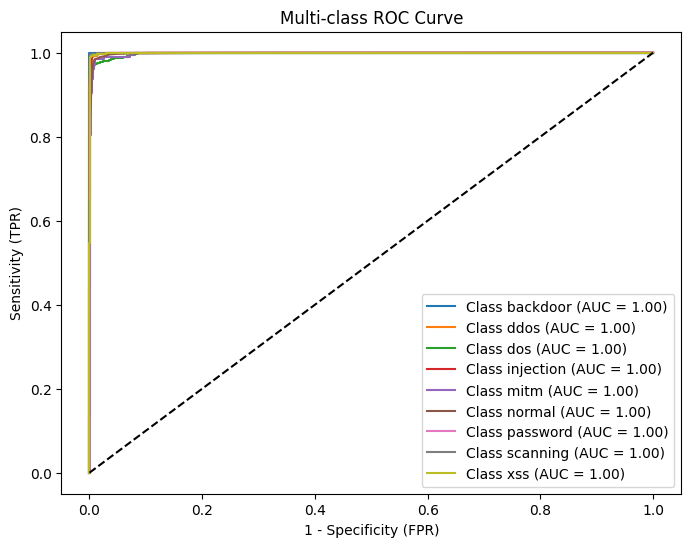

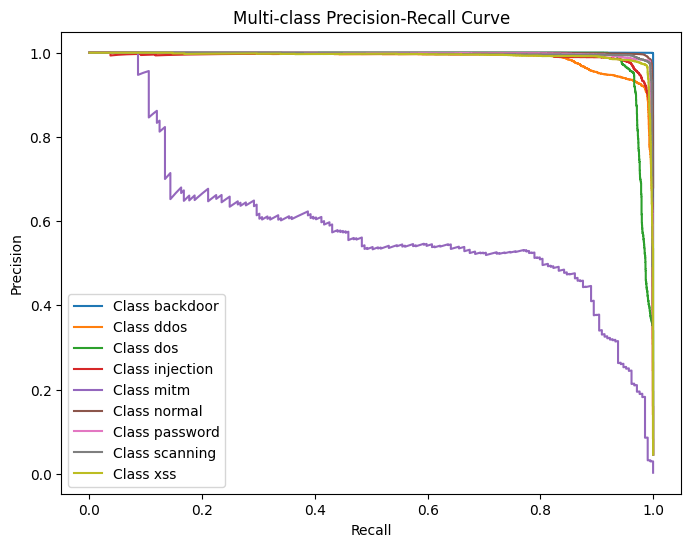

In [8]:
import seaborn as sns

# original class labels (what was in df[TARGET_TYPE])
print(type_encoder.classes_)

# numeric codes assigned
for i, cls in enumerate(type_encoder.classes_):
    print(f"Encoded class {i} -> {cls}")


# Print classification report
y_pred_probs = model.predict(X_test_seq)
y_pred_classes = y_pred_probs.argmax(axis=1)
y_true_classes = y_test_seq.argmax(axis=1)
print(classification_report(y_true_classes, y_pred_classes))

#confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# For multi-class, FNR and FPR are not simply tn, fp, fn, tp.
# If you want per-class FNR/FPR:
fnr = []
fpr = []
for i in range(cm.shape[0]):
    fn = cm[i, :].sum() - cm[i, i]
    tp = cm[i, i]
    fp = cm[:, i].sum() - cm[i, i]
    tn = cm.sum() - (tp + fn + fp)
    fnr.append(fn / (fn + tp) if (fn + tp) > 0 else 0)
    fpr.append(fp / (fp + tn) if (fp + tn) > 0 else 0)

results_df = pd.DataFrame({
    "Class": type_encoder.classes_,
    "FNR": fnr,
    "FPR": fpr
})
print(results_df.to_string(index=False))


# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=type_encoder.classes_,
            yticklabels=type_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


# plot validation loss and accuracy
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Loss and Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Loss/Accuracy')
plt.legend()
plt.show()

# sensitivity vs 1-specificity plot for multi-class
plt.figure(figsize=(8, 6))
for i in range(len(type_encoder.classes_)):
    fpr_i, tpr_i, _ = roc_curve(y_test_seq[:, i], y_pred_probs[:, i])
    plt.plot(fpr_i, tpr_i, label=f'Class {type_encoder.classes_[i]} (AUC = {roc_auc_score(y_test_seq[:, i], y_pred_probs[:, i]):.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.title('Multi-class ROC Curve')
plt.xlabel('1 - Specificity (FPR)')
plt.ylabel('Sensitivity (TPR)')
plt.legend()
plt.show()  

# precision-recall curve for multi-class
plt.figure(figsize=(8, 6))
for i in range(len(type_encoder.classes_)):
    precision_i, recall_i, _ = precision_recall_curve(y_test_seq[:, i], y_pred_probs[:, i])
    plt.plot(recall_i, precision_i, label=f'Class {type_encoder.classes_[i]}')
plt.title('Multi-class Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision') 
plt.legend()
plt.show()



In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GRU, Dense, Dropout, Flatten, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adagrad
from tensorflow.keras.metrics import Precision, Recall, AUC
from tensorflow.keras.regularizers import l2
from sklearn.metrics import (confusion_matrix, accuracy_score, recall_score, precision_score, 
                           f1_score, matthews_corrcoef, roc_auc_score, classification_report, 
                           roc_curve, precision_recall_curve)
import matplotlib.pyplot as plt
import numpy as np

def pearson_correlation_feature_selection(X, threshold=0.8):
    """
    Algorithm 1: Feature Selection using Pearson's Correlation
    Input: Data instances
    Output: Optimized feature set Cf
    """
    # Calculate correlation matrix
    corr_matrix = np.corrcoef(X.T)
    n_features = X.shape[1]
    
    # Find highly correlated features
    highly_correlated = set()
    Cf = set(range(n_features))  # Start with all features
    
    for i in range(n_features):
        for j in range(i + 1, n_features):
            if abs(corr_matrix[i, j]) > threshold:
                highly_correlated.add(j)  # Remove feature j
    
    # Return optimized feature set
    Cf = Cf - highly_correlated
    return list(Cf)

# Apply feature selection (assuming X_train_seq is your feature data)
print("Applying Pearson Correlation Feature Selection...")
selected_features = pearson_correlation_feature_selection(X_train_seq.reshape(X_train_seq.shape[0], -1))
print(f"Selected {len(selected_features)} features out of {X_train_seq.shape[1] * X_train_seq.shape[2]}")

# Model definition - CNN-GRU Architecture
model = Sequential([
    # First Convolutional Layer (activation='relu')
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu',
        padding='same',
        input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])
    ),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    
    # Second Convolutional Layer (activation='relu')
    Conv1D(
        filters=128,
        kernel_size=3,
        activation='relu',
        padding='same'
    ),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    
    # Third Convolutional Layer (activation='relu')
    Conv1D(
        filters=256,
        kernel_size=3,
        activation='relu',
        padding='same'
    ),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    
    # First GRU Layer (activation='relu')
    GRU(
        128,
        activation='relu',
        return_sequences=True,
        recurrent_dropout=0.2,
        kernel_regularizer=l2(1e-5)
    ),
    BatchNormalization(),
    Dropout(0.4),
    
    # Second GRU Layer (activation='relu')
    GRU(
        64,
        activation='relu',
        recurrent_dropout=0.2,
        kernel_regularizer=l2(1e-5)
    ),
    BatchNormalization(),
    Dropout(0.4),
    
    # Dense layers for final classification
    Dense(32, activation='relu'),
    Dropout(0.2),
    
    Dense(9, activation='softmax')
])

model.summary()

# Model compilation as per Algorithm 1
optimizer = Adagrad(
    learning_rate=0.001,
    clipnorm=1.0
)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',  # As specified in algorithm
    metrics=[
        'accuracy',
        AUC(name='auc'),
        Recall(name='recall'),
        Precision(name='precision')
    ]
)

# Enhanced callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,  # Increased patience for CNN-GRU
    mode='min',
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

print("Training CNN-GRU Model as per Algorithm 1...")
print("Architecture: 3 Convolutional Layers + 2 GRU Layers")

# Train the model
history = model.fit(
    X_train_seq_final, y_train_seq_final,
    validation_data=(X_val_seq, y_val_seq),
    epochs=25,  # Increased epochs for CNN-GRU
    batch_size=128,
    shuffle=True,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Evaluate the model
print("\nEvaluating CNN-GRU Model...")
results = model.evaluate(X_test_seq, y_test_seq, verbose=2)

print("CNN-GRU Model Results:")
print("Test Loss: {:.4f}".format(results[0]))
print("Test Accuracy: {:.4f}".format(results[1]))
print("Test AUC: {:.4f}".format(results[2]))
print("Test Recall: {:.4f}".format(results[3]))
print("Test Precision: {:.4f}".format(results[4]))

# Generate predictions for confusion matrix
y_pred = model.predict(X_test_seq)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test_seq, axis=1)

# Generate confusion matrix as per Algorithm 1 output
print("\nGenerating Confusion Matrix Cm*m...")
cm = confusion_matrix(y_true_classes, y_pred_classes)
print("Confusion Matrix:")
print(cm)

# Calculate additional metrics
accuracy = accuracy_score(y_true_classes, y_pred_classes)
precision = precision_score(y_true_classes, y_pred_classes, average='weighted')
recall = recall_score(y_true_classes, y_pred_classes, average='weighted')
f1 = f1_score(y_true_classes, y_pred_classes, average='weighted')
mcc = matthews_corrcoef(y_true_classes, y_pred_classes)

print("\nComprehensive Metrics:")
print("Accuracy: {:.4f}".format(accuracy))
print("Precision: {:.4f}".format(precision))
print("Recall: {:.4f}".format(recall))
print("F1-Score: {:.4f}".format(f1))
print("MCC: {:.4f}".format(mcc))

# Calculate FPR and TPR for each class
fpr = {}
tpr = {}
for i in range(9):
    fpr[i], tpr[i], _ = roc_curve(y_test_seq[:, i], y_pred[:, i])

print("\nFPR and TPR values calculated for each class")

# Plot training history
plt.figure(figsize(15, 5))

plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history.history['recall'], label='Training Recall')
plt.plot(history.history['val_recall'], label='Validation Recall')
plt.title('Model Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend()

plt.tight_layout()
plt.show()

# Classification report
print("\nDetailed Classification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=[
    'backdoor', 'ddos', 'dos', 'injection', 'mitm', 'normal', 'password', 'scanning', 'xss'
]))

def calculate_fnr_fpr(cm):
    """
    Calculate False Negative Rate and False Positive Rate from confusion matrix
    """
    fnr_list = []
    fpr_list = []
    
    for i in range(len(cm)):
        # False Negative Rate (FNR) = FN / (TP + FN)
        fn = np.sum(cm[i, :]) - cm[i, i]  # Sum of row i minus diagonal
        tp_plus_fn = np.sum(cm[i, :])
        fnr = fn / tp_plus_fn if tp_plus_fn > 0 else 0
        
        # False Positive Rate (FPR) = FP / (FP + TN)
        fp = np.sum(cm[:, i]) - cm[i, i]  # Sum of column i minus diagonal
        tn = np.sum(cm) - (np.sum(cm[i, :]) + np.sum(cm[:, i]) - cm[i, i])
        fpr_val = fp / (fp + tn) if (fp + tn) > 0 else 0
        
        fnr_list.append(fnr)
        fpr_list.append(fpr_val)
    
    return fnr_list, fpr_list

# Calculate FNR and FPR
fnr, fpr = calculate_fnr_fpr(cm)
print("\nClass-wise FNR and FPR:")
for i, class_name in enumerate(['backdoor', 'ddos', 'dos', 'injection', 'mitm', 'normal', 'password', 'scanning', 'xss']):
    print(f"{class_name:10} FNR: {fnr[i]:.6f}  FPR: {fpr[i]:.6f}")

Applying Pearson Correlation Feature Selection...
Selected 350 features out of 440


/home/jinesh-subedi/htdocs/thesis/thesisStudy/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 10, 64)         │         8,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 10, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 5, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 5, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 2, 256)         │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 2, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 1, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 1, 128)         │       148,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 1, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,185 (1.23 MB)

...

2206/2206 ━━━━━━━━━━━━━━━━━━━━ 44s 11ms/step - accuracy: 0.4320 - auc: 0.7458 - loss: 1.9435 - precision: 0.6096 - recall: 0.2156 - val_accuracy: 0.6816 - val_auc: 0.8250 - val_loss: 1.4014 - val_precision: 0.6880 - val_recall: 0.3398 - learning_rate: 0.0010
Epoch 2/25
2206/2206 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6176 - auc: 0.8231 - loss: 1.5761 - precision: 0.6764 - recall: 0.4043 - val_accuracy: 0.6818 - val_auc: 0.8330 - val_loss: 1.3294 - val_precision: 0.6862 - val_recall: 0.5529 - learning_rate: 0.0010
Epoch 3/25
2206/2206 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6448 - auc: 0.8296 - loss: 1.5112 - precision: 0.6813 - recall: 0.4527 - val_accuracy: 0.6818 - val_auc: 0.8385 - val_loss: 1.3104 - val_precision: 0.6857 - val_recall: 0.5969 - learning_rate: 0.0010
Epoch 4/25
2206/2206 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6555 - auc: 0.8327 - loss: 1.4763 - precision: 0.6828 - recall: 0.4719 - val_accuracy: 0.6818 - val_auc: 0.8418 - val_loss: 1.3001 - val_

2025-11-16 20:35:27.029037: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-16 20:35:27.029064: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-16 20:35:28.219908: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_34', 24 bytes spill stores, 24 bytes spill loads



2757/2757 - 7s - 3ms/step - accuracy: 0.6802 - auc: 0.8852 - loss: 1.2269 - precision: 0.7180 - recall: 0.6174
CNN-GRU Model Results:
Test Loss: 1.2269
Test Accuracy: 0.6802
Test AUC: 0.8852
Test Recall: 0.6174
Test Precision: 0.7180
2757/2757 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step

Generating Confusion Matrix Cm*m...
Confusion Matrix:
[[    0     0     0     0     0  3999     0     0     0]
 [    0     0     0     0     0  3999     0     0     0]
 [    0     0     0     0     0  4000     0     0     0]
 [    0     0     0     0     0  3999     0     0     0]
 [    0     0     0     0     0   209     0     0     0]
 [    0     0     0     0     0 59995     0     0     0]
 [    0     0     0     0     0  3999     0     0     0]
 [    0     0     0     0     0  4000     0     0     0]
 [    0     0     0     0     0  4000     0     0     0]]

Comprehensive Metrics:
Accuracy: 0.6802
Precision: 0.4627
Recall: 0.6802
F1-Score: 0.5508
MCC: 0.0000

FPR and TPR values calculated for each class


/home/jinesh-subedi/htdocs/thesis/thesisStudy/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


NameError: name 'figsize' is not defined